In [1]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib
import os
from datetime import datetime

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports OK")
print(f"TensorFlow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Imports OK
TensorFlow version: 2.16.1
Numpy version: 1.26.4
Pandas version: 2.3.3


In [2]:
# ============================================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================================

print("\n" + "="*60)
print("📂 CHARGEMENT DES DONNÉES")
print("="*60)

# Chemins
DATA_DIR = "../data/water_training_split"
MODEL_DIR = "api/ml"

# Créer le dossier de sortie si besoin
os.makedirs(MODEL_DIR, exist_ok=True)

# Chargement
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"✓ Train: {train_df.shape[0]} échantillons")
print(f"✓ Val:   {val_df.shape[0]} échantillons")
print(f"✓ Test:  {test_df.shape[0]} échantillons")

# Affichage des premières lignes
print("\n📊 Aperçu des données (train):")
print(train_df.head())


📂 CHARGEMENT DES DONNÉES
✓ Train: 700 échantillons
✓ Val:   150 échantillons
✓ Test:  150 échantillons

📊 Aperçu des données (train):
   temperature_celsius  humidity_percent  rainfall_mm  evapotranspiration_mm  \
0                 25.1              78.1         38.1                    3.9   
1                 27.7              84.6          7.5                    4.4   
2                 29.0              84.1          8.5                    4.2   
3                 20.4              80.4         12.5                    4.2   
4                 29.2              92.2          4.5                    5.0   

   wind_speed_kmh  soil_moisture_percent soil_type growth_stage  \
0             6.7                   82.7      peat  germination   
1            23.0                   88.3      clay   vegetative   
2            15.0                   68.2      peat  germination   
3            18.9                   40.4      peat   maturation   
4            22.8                   70.3     loam


📊 ANALYSE EXPLORATOIRE

📈 Statistiques de la variable cible (water_need_mm_per_day):
count    700.000000
mean      64.797486
std       26.074515
min        6.250000
25%       43.777500
50%       61.485000
75%       93.572500
max      100.000000
Name: water_need_mm_per_day, dtype: float64
✓ Graphiques sauvegardés: api/ml/eda_analysis.png

🔗 Corrélations avec la variable cible:
water_need_mm_per_day    1.000000
wind_speed_kmh           0.061792
temperature_celsius     -0.000596
evapotranspiration_mm   -0.002175
humidity_percent        -0.029731
rainfall_mm             -0.202689
soil_moisture_percent   -0.239359
Name: water_need_mm_per_day, dtype: float64


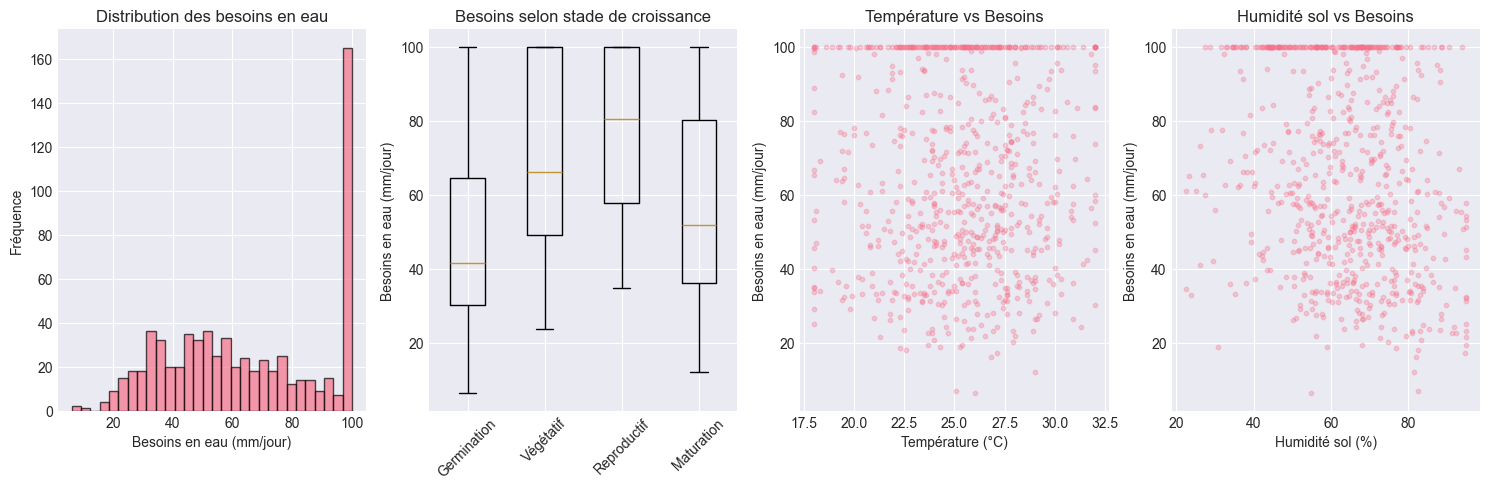

In [5]:

# ============================================================================
# 2. ANALYSE EXPLORATOIRE (EDA)
# ============================================================================

print("\n" + "="*60)
print("📊 ANALYSE EXPLORATOIRE")
print("="*60)

# Statistiques descriptives
print("\n📈 Statistiques de la variable cible (water_need_mm_per_day):")
print(train_df['water_need_mm_per_day'].describe())

# Distribution de la cible
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.hist(train_df['water_need_mm_per_day'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Besoins en eau (mm/jour)')
plt.ylabel('Fréquence')
plt.title('Distribution des besoins en eau')

plt.subplot(1, 4, 2)
plt.boxplot([
    train_df[train_df['growth_stage']=='germination']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='vegetative']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='reproductive']['water_need_mm_per_day'],
    train_df[train_df['growth_stage']=='maturation']['water_need_mm_per_day']
])
plt.xticks([1, 2, 3, 4], ['Germination', 'Végétatif', 'Reproductif', 'Maturation'], rotation=45)
plt.ylabel('Besoins en eau (mm/jour)')
plt.title('Besoins selon stade de croissance')

plt.subplot(1, 4, 3)
plt.scatter(train_df['temperature_celsius'], train_df['water_need_mm_per_day'], alpha=0.3, s=10)
plt.xlabel('Température (°C)')
plt.ylabel('Besoins en eau (mm/jour)')
plt.title('Température vs Besoins')

plt.subplot(1, 4, 4)
plt.scatter(train_df['soil_moisture_percent'], train_df['water_need_mm_per_day'], alpha=0.3, s=10)
plt.xlabel('Humidité sol (%)')
plt.ylabel('Besoins en eau (mm/jour)')
plt.title('Humidité sol vs Besoins')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_analysis.png', dpi=150)
print(f"✓ Graphiques sauvegardés: {MODEL_DIR}/eda_analysis.png")

# Matrice de corrélation
print("\n🔗 Corrélations avec la variable cible:")
numerical_features = [
    'temperature_celsius',
    'humidity_percent',
    'rainfall_mm',
    'evapotranspiration_mm',
    'wind_speed_kmh',
    'soil_moisture_percent'
]

correlations = train_df[numerical_features + ['water_need_mm_per_day']].corr()['water_need_mm_per_day'].sort_values(ascending=False)
print(correlations)


In [6]:
 
# ============================================================================
# 3. PRÉPARATION DES DONNÉES (8 FEATURES)
# ============================================================================

print("\n" + "="*60)
print("🔧 PRÉPARATION DES DONNÉES (8 FEATURES)")
print("="*60)

# Features à utiliser (8 au total)
NUMERICAL_FEATURES = [
    'temperature_celsius',
    'humidity_percent', 
    'rainfall_mm',
    'evapotranspiration_mm',
    'wind_speed_kmh',
    'soil_moisture_percent'
]

CATEGORICAL_FEATURES = [
    'growth_stage_encoded'  # ✅ NOUVEAU (0=germination, 1=vegetative, 2=reproductive, 3=maturation)
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES  # 8 features total
TARGET = 'water_need_mm_per_day'

print(f"✓ Features numériques: {len(NUMERICAL_FEATURES)}")
print(f"✓ Features catégorielles: {len(CATEGORICAL_FEATURES)}")
print(f"✓ Total features: {len(ALL_FEATURES)}")
print(f"✓ Features: {ALL_FEATURES}")

# Extraction X et y
X_train = train_df[ALL_FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[ALL_FEATURES].values
y_val = val_df[TARGET].values

X_test = test_df[ALL_FEATURES].values
y_test = test_df[TARGET].values

print(f"\n✓ X_train shape: {X_train.shape}")
print(f"✓ X_val shape: {X_val.shape}")
print(f"✓ X_test shape: {X_test.shape}")

# Normalisation (important pour les réseaux de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Sauvegarder le scaler
joblib.dump(scaler, f'{MODEL_DIR}/water_scaler.pkl')
print(f"✓ Scaler sauvegardé: {MODEL_DIR}/water_scaler.pkl")



🔧 PRÉPARATION DES DONNÉES (8 FEATURES)
✓ Features numériques: 6
✓ Features catégorielles: 1
✓ Total features: 7
✓ Features: ['temperature_celsius', 'humidity_percent', 'rainfall_mm', 'evapotranspiration_mm', 'wind_speed_kmh', 'soil_moisture_percent', 'growth_stage_encoded']

✓ X_train shape: (700, 7)
✓ X_val shape: (150, 7)
✓ X_test shape: (150, 7)
✓ Scaler sauvegardé: api/ml/water_scaler.pkl



🌲 ENTRAÎNEMENT RANDOM FOREST
⏳ Entraînement en cours...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished



📊 Métriques Train RF:
   MAE:  9.49 mm/jour
   RMSE: 11.13 mm/jour
   R²:   0.8174

📊 Métriques Validation RF:
   MAE:  20.14 mm/jour
   RMSE: 23.21 mm/jour
   R²:   0.1725

📊 Métriques Test RF:
   MAE:  18.65 mm/jour
   RMSE: 22.00 mm/jour
   R²:   0.2820

🔍 Importance des features (Random Forest):
                 feature  importance
5  soil_moisture_percent    0.222258
6   growth_stage_encoded    0.207400
2            rainfall_mm    0.174846
4         wind_speed_kmh    0.106194
3  evapotranspiration_mm    0.098415
1       humidity_percent    0.096033
0    temperature_celsius    0.094855
✓ Importance features sauvegardée: api/ml/feature_importance_rf.png
✓ Modèle RF sauvegardé: api/ml/water_model_rf.pkl


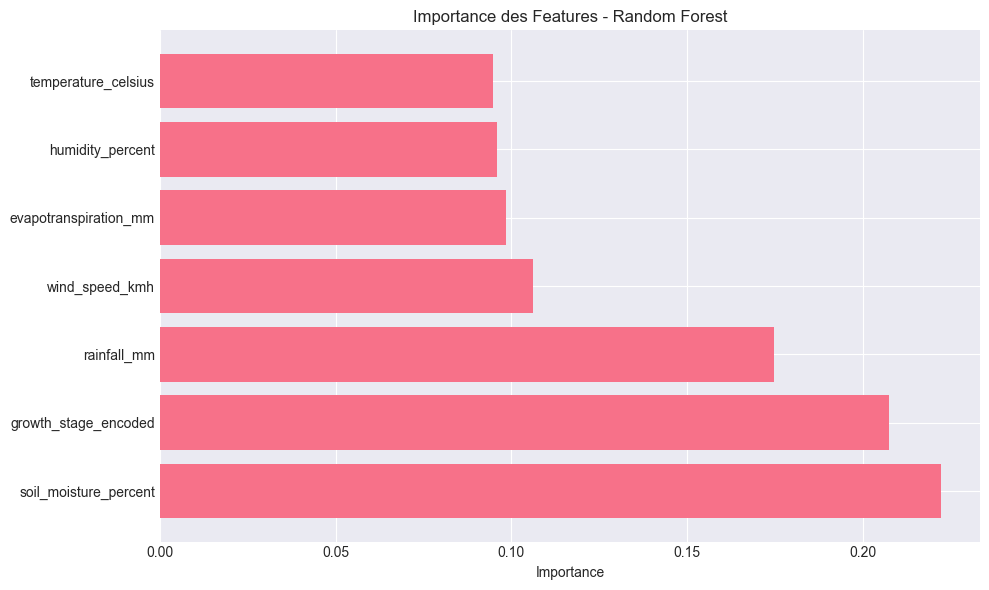

In [7]:

# ============================================================================
# 4. MODÈLE 1 : RANDOM FOREST (BASELINE)
# ============================================================================

print("\n" + "="*60)
print("🌲 ENTRAÎNEMENT RANDOM FOREST")
print("="*60)

# Entraînement
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("⏳ Entraînement en cours...")
rf_model.fit(X_train, y_train)

# Prédictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Évaluation
def evaluate_model(y_true, y_pred, set_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n📊 Métriques {set_name}:")
    print(f"   MAE:  {mae:.2f} mm/jour")
    print(f"   RMSE: {rmse:.2f} mm/jour")
    print(f"   R²:   {r2:.4f}")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, "Train RF")
rf_val_metrics = evaluate_model(y_val, y_val_pred_rf, "Validation RF")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, "Test RF")

# Importance des features
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔍 Importance des features (Random Forest):")
print(feature_importance)

# Visualiser l'importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Importance des Features - Random Forest')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/feature_importance_rf.png', dpi=150)
print(f"✓ Importance features sauvegardée: {MODEL_DIR}/feature_importance_rf.png")

# Sauvegarder le modèle
joblib.dump(rf_model, f'{MODEL_DIR}/water_model_rf.pkl')
print(f"✓ Modèle RF sauvegardé: {MODEL_DIR}/water_model_rf.pkl")


In [10]:

# ============================================================================
# 5. MODÈLE 2 : LSTM (DEEP LEARNING)
# ============================================================================

print("\n" + "="*60)
print("🧠 ENTRAÎNEMENT LSTM (8 FEATURES)")
print("="*60)

# Pour LSTM, on doit reshaper les données (samples, timesteps, features)
# Ici on utilise timesteps=1 car chaque prédiction est indépendante
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"✓ X_train_lstm shape: {X_train_lstm.shape}")
print(f"   (samples, timesteps, features) = ({X_train_lstm.shape[0]}, {X_train_lstm.shape[1]}, {X_train_lstm.shape[2]})")

# Architecture du modèle (adaptée pour 8 features)
def create_lstm_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        # Couche LSTM
        layers.LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        
        # Couches denses
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        
        layers.Dense(16, activation='relu'),
        
        # Sortie
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Créer le modèle
lstm_model = create_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))

print("\n📐 Architecture du modèle:")
lstm_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{MODEL_DIR}/water_model_lstm_best.keras',  # ✅ .keras au lieu de .h5
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# Entraînement
print("\n⏳ Entraînement en cours...")
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Sauvegarder le modèle final
lstm_model.save(f'{MODEL_DIR}/water_model.keras')  # ✅ Format .keras recommandé
print(f"✓ Modèle LSTM sauvegardé: {MODEL_DIR}/water_model.keras")

# Prédictions
y_train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()
y_val_pred_lstm = lstm_model.predict(X_val_lstm).flatten()
y_test_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

# Évaluation
lstm_train_metrics = evaluate_model(y_train, y_train_pred_lstm, "Train LSTM")
lstm_val_metrics = evaluate_model(y_val, y_val_pred_lstm, "Validation LSTM")
lstm_test_metrics = evaluate_model(y_test, y_test_pred_lstm, "Test LSTM")


🧠 ENTRAÎNEMENT LSTM (8 FEATURES)
✓ X_train_lstm shape: (700, 1, 7)
   (samples, timesteps, features) = (700, 1, 7)

📐 Architecture du modèle:


C:\Users\PC\anaconda3\envs\tf310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 1, 64)               │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,449 (126.75 KB)

 Trainable params: 32,449 (126.75 KB)

 Non-trainable params: 0 (0.00 B)


⏳ Entraînement en cours...
Epoch 1/100
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4858.9768 - mae: 64.6118
Epoch 1: val_loss improved from None to 4668.29297, saving model to api/ml/water_model_lstm_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 4864.6519 - mae: 64.6962 - val_loss: 4668.2930 - val_mae: 63.3811 - learning_rate: 0.0010
Epoch 2/100
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4877.8506 - mae: 64.9876
Epoch 2: val_loss improved from 4668.29297 to 4582.20996, saving model to api/ml/water_model_lstm_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4814.1152 - mae: 64.3019 - val_loss: 4582.2100 - val_mae: 62.6953 - learning_rate: 0.0010
Epoch 3/100
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4616.2448 - mae: 62.7438
Epoch 3: val_loss improved from 4582.20996 to 4257.68604, saving model to api/ml/water_model_lstm_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4644.0298 - mae: 62.9636 - val_loss: 4257.6860 - val_mae: 60.0340 - learnin


📊 COMPARAISON DES MODÈLES
       Modèle  MAE Test  RMSE Test  R² Test
Random Forest 18.653352  21.995187 0.281999
         LSTM 19.332837  21.758786 0.297350

🏆 Meilleur modèle (MAE): Random Forest
✓ Courbes sauvegardées: api/ml/training_curves.png
✓ Comparaison sauvegardée: api/ml/predictions_comparison.png


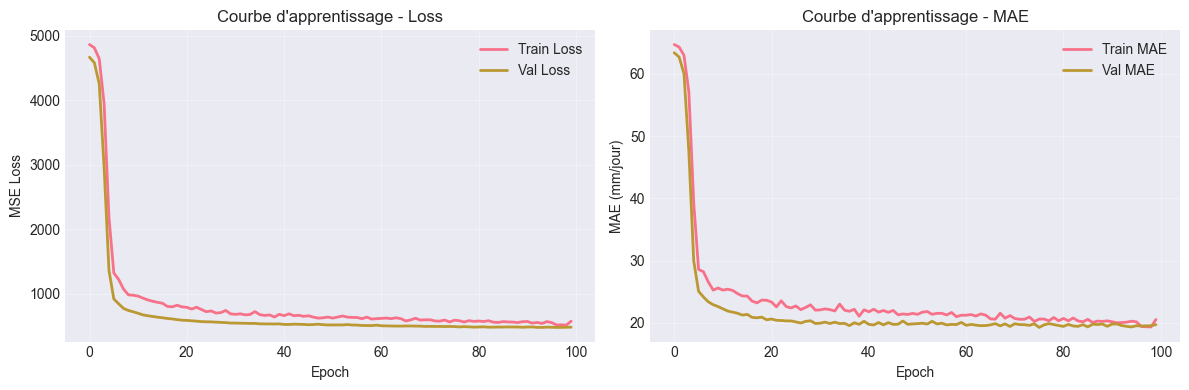

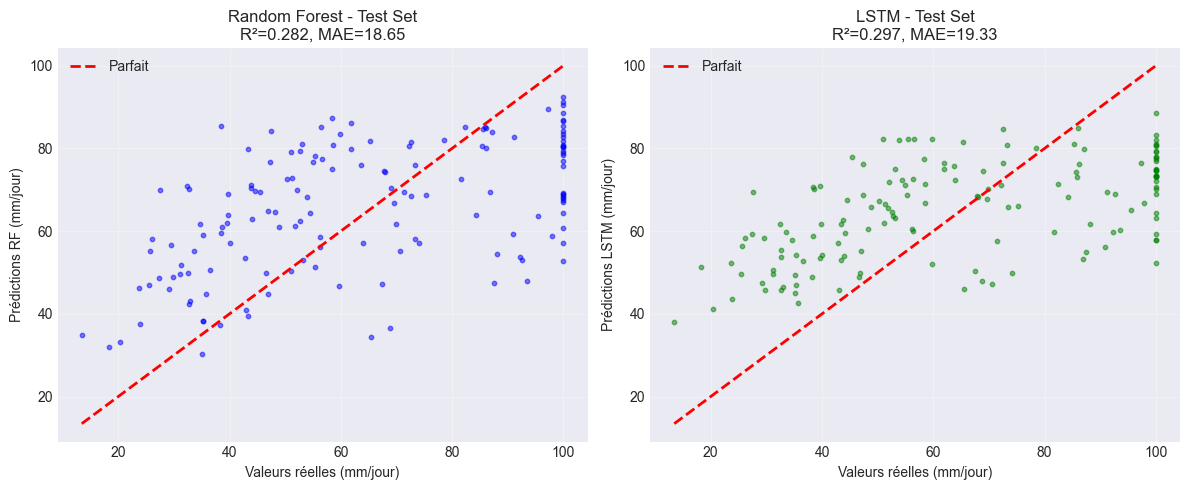

In [11]:

# ============================================================================
# 6. COMPARAISON DES MODÈLES
# ============================================================================

print("\n" + "="*60)
print("📊 COMPARAISON DES MODÈLES")
print("="*60)

comparison = pd.DataFrame({
    'Modèle': ['Random Forest', 'LSTM'],
    'MAE Test': [rf_test_metrics['mae'], lstm_test_metrics['mae']],
    'RMSE Test': [rf_test_metrics['rmse'], lstm_test_metrics['rmse']],
    'R² Test': [rf_test_metrics['r2'], lstm_test_metrics['r2']]
})

print(comparison.to_string(index=False))

# Déterminer le meilleur modèle
best_model = "Random Forest" if rf_test_metrics['mae'] < lstm_test_metrics['mae'] else "LSTM"
print(f"\n🏆 Meilleur modèle (MAE): {best_model}")

# Visualisation de la courbe d'apprentissage LSTM
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Courbe d\'apprentissage - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE (mm/jour)')
plt.title('Courbe d\'apprentissage - MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', dpi=150)
print(f"✓ Courbes sauvegardées: {MODEL_DIR}/training_curves.png")

# Prédictions vs Réalité
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, s=10, c='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Parfait')
plt.xlabel('Valeurs réelles (mm/jour)')
plt.ylabel('Prédictions RF (mm/jour)')
plt.title(f'Random Forest - Test Set\nR²={rf_test_metrics["r2"]:.3f}, MAE={rf_test_metrics["mae"]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred_lstm, alpha=0.5, s=10, c='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Parfait')
plt.xlabel('Valeurs réelles (mm/jour)')
plt.ylabel('Prédictions LSTM (mm/jour)')
plt.title(f'LSTM - Test Set\nR²={lstm_test_metrics["r2"]:.3f}, MAE={lstm_test_metrics["mae"]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/predictions_comparison.png', dpi=150)
print(f"✓ Comparaison sauvegardée: {MODEL_DIR}/predictions_comparison.png")


In [12]:

# ============================================================================
# 7. TEST RAPIDE DU MODÈLE
# ============================================================================

print("\n" + "="*60)
print("🧪 TEST RAPIDE DU MODÈLE")
print("="*60)

# Charger le modèle sauvegardé
loaded_model = keras.models.load_model(f'{MODEL_DIR}/water_model.keras')
loaded_scaler = joblib.load(f'{MODEL_DIR}/water_scaler.pkl')

# Exemple de prédiction (8 features)
sample = {
    'temperature_celsius': 28.5,
    'humidity_percent': 75.0,
    'rainfall_mm': 2.0,
    'evapotranspiration_mm': 5.5,
    'wind_speed_kmh': 12.0,
    'soil_moisture_percent': 65.0,
    'solar_radiation_mj': 22.5,
    'growth_stage_encoded': 1  # 1 = vegetative
}

sample_array = np.array([[sample[f] for f in ALL_FEATURES]])
sample_scaled = loaded_scaler.transform(sample_array)
sample_lstm = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))

prediction = loaded_model.predict(sample_lstm, verbose=0)[0][0]

print(f"\n📊 Exemple de prédiction:")
print(f"   Température: {sample['temperature_celsius']}°C")
print(f"   Humidité air: {sample['humidity_percent']}%")
print(f"   Pluie: {sample['rainfall_mm']} mm")
print(f"   ET0: {sample['evapotranspiration_mm']} mm")
print(f"   Vent: {sample['wind_speed_kmh']} km/h")
print(f"   Humidité sol: {sample['soil_moisture_percent']}%")
print(f"   Radiation solaire: {sample['solar_radiation_mj']} MJ/m²")
print(f"   Stade croissance: {'vegetative' if sample['growth_stage_encoded']==1 else 'autre'}")
print(f"\n   → Besoin en eau prédit: {prediction:.2f} mm/jour")

# Test sur différents stades de croissance
print("\n📊 Prédictions selon stades de croissance:")
stages = {0: 'germination', 1: 'vegetative', 2: 'reproductive', 3: 'maturation'}

for stage_code, stage_name in stages.items():
    sample['growth_stage_encoded'] = stage_code
    sample_array = np.array([[sample[f] for f in ALL_FEATURES]])
    sample_scaled = loaded_scaler.transform(sample_array)
    sample_lstm = sample_scaled.reshape((1, 1, sample_scaled.shape[1]))
    pred = loaded_model.predict(sample_lstm, verbose=0)[0][0]
    print(f"   {stage_name:15s}: {pred:.2f} mm/jour")



🧪 TEST RAPIDE DU MODÈLE

📊 Exemple de prédiction:
   Température: 28.5°C
   Humidité air: 75.0%
   Pluie: 2.0 mm
   ET0: 5.5 mm
   Vent: 12.0 km/h
   Humidité sol: 65.0%
   Radiation solaire: 22.5 MJ/m²
   Stade croissance: vegetative

   → Besoin en eau prédit: 69.79 mm/jour

📊 Prédictions selon stades de croissance:
   germination    : 53.46 mm/jour
   vegetative     : 69.79 mm/jour
   reproductive   : 71.47 mm/jour
   maturation     : 62.11 mm/jour


In [13]:

# ============================================================================
# 8. RÉSUMÉ FINAL
# ============================================================================

print("\n" + "="*60)
print("✅ ENTRAÎNEMENT TERMINÉ")
print("="*60)

print(f"\n📦 Fichiers sauvegardés dans {MODEL_DIR}/:")
print(f"   ✓ water_model.keras         (Modèle LSTM)")
print(f"   ✓ water_model_rf.pkl        (Modèle Random Forest)")
print(f"   ✓ water_scaler.pkl          (Scaler StandardScaler)")
print(f"   ✓ eda_analysis.png          (Analyse exploratoire)")
print(f"   ✓ feature_importance_rf.png (Importance features RF)")
print(f"   ✓ training_curves.png       (Courbes d'apprentissage)")
print(f"   ✓ predictions_comparison.png (Comparaison modèles)")

print(f"\n🎯 Performances finales:")
print(f"   Random Forest - MAE: {rf_test_metrics['mae']:.2f} mm/jour (R²: {rf_test_metrics['r2']:.3f})")
print(f"   LSTM          - MAE: {lstm_test_metrics['mae']:.2f} mm/jour (R²: {lstm_test_metrics['r2']:.3f})")

print(f"\n💡 Pour utiliser le modèle:")
print(f"   1. Importer: from tensorflow import keras")
print(f"   2. Charger: model = keras.models.load_model('{MODEL_DIR}/water_model.keras')")
print(f"   3. Charger scaler: scaler = joblib.load('{MODEL_DIR}/water_scaler.pkl')")
print(f"   4. Prédire avec 8 features (voir exemple ci-dessus)")

print("\n" + "="*60)


✅ ENTRAÎNEMENT TERMINÉ

📦 Fichiers sauvegardés dans api/ml/:
   ✓ water_model.keras         (Modèle LSTM)
   ✓ water_model_rf.pkl        (Modèle Random Forest)
   ✓ water_scaler.pkl          (Scaler StandardScaler)
   ✓ eda_analysis.png          (Analyse exploratoire)
   ✓ feature_importance_rf.png (Importance features RF)
   ✓ training_curves.png       (Courbes d'apprentissage)
   ✓ predictions_comparison.png (Comparaison modèles)

🎯 Performances finales:
   Random Forest - MAE: 18.65 mm/jour (R²: 0.282)
   LSTM          - MAE: 19.33 mm/jour (R²: 0.297)

💡 Pour utiliser le modèle:
   1. Importer: from tensorflow import keras
   2. Charger: model = keras.models.load_model('api/ml/water_model.keras')
   3. Charger scaler: scaler = joblib.load('api/ml/water_scaler.pkl')
   4. Prédire avec 8 features (voir exemple ci-dessus)

